In [9]:
# importing necessary library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout

In [10]:
data=pd.read_csv("/content/Amazon_Stock_Price.csv")
df=data.copy()

In [11]:
# checking top 5 rows
df.head()

,Unnamed: 0,Date,Open,High,Low,Close,Volume
0,0,2000-01-03,4.075000,4.478125,3.952344,4.468750,322352000
1,1,2000-01-04,4.268750,4.575000,4.087500,4.096875,349748000
2,2,2000-01-05,3.525000,3.756250,3.400000,3.487500,769148000
3,3,2000-01-06,3.565625,3.634375,3.200000,3.278125,375040000
4,4,2000-01-07,3.350000,3.525000,3.309375,3.478125,210108000


In [12]:
# checking data types or other information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6050 entries, 0 to 6049
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  6050 non-null   int64  
 1   Date        6050 non-null   object 
 2   Open        6050 non-null   float64
 3   High        6050 non-null   float64
 4   Low         6050 non-null   float64
 5   Close       6050 non-null   float64
 6   Volume      6050 non-null   int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 331.0+ KB


In [13]:
# checking missing values
print(df.isnull().sum())

Unnamed: 0    0
Date          0
Open          0
High          0
Low           0
Close         0
Volume        0
dtype: int64


In [14]:
# Convert 'Date' column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Drop the 'Unnamed: 0' column
df = df.drop(columns=['Unnamed: 0'])

# Sort by 'Date'
df = df.sort_values(by='Date')

# Set 'Date' column as index
df = df.set_index('Date')

# Display the resulting DataFrame
print(df)


                  Open        High         Low       Close     Volume
Date                                                                 
2000-01-03    4.075000    4.478125    3.952344    4.468750  322352000
2000-01-04    4.268750    4.575000    4.087500    4.096875  349748000
2000-01-05    3.525000    3.756250    3.400000    3.487500  769148000
2000-01-06    3.565625    3.634375    3.200000    3.278125  375040000
2000-01-07    3.350000    3.525000    3.309375    3.478125  210108000
...                ...         ...         ...         ...        ...
2024-01-12  155.389999  156.199997  154.009995  154.619995   40460300
2024-01-16  153.529999  154.990005  152.149994  153.160004   41384600
2024-01-17  151.490005  152.149994  149.910004  151.710007   34953400
2024-01-18  152.770004  153.779999  151.820007  153.500000   37850200
2024-01-19  153.830002  155.759995  152.740005  155.339996   51033700

[6050 rows x 5 columns]


#### Preprocessing

In [15]:
# Use 'Close' price
data = df['Close'].values.reshape(-1, 1)

# Normalize the data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [16]:
# Create sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

SEQ_LEN = 60
X, y = create_sequences(scaled_data, SEQ_LEN)


In [17]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [18]:
# Build GRU model
model = Sequential()
model.add(GRU(units=50, return_sequences=True, input_shape=(SEQ_LEN, 1)))
model.add(Dropout(0.2))
model.add(GRU(units=50))
model.add(Dropout(0.2))
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 60, 50)         │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,301 (91.02 KB)

 Trainable params: 23,301 (91.02 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1)

# Predictions
predicted = model.predict(X_test)
predicted_prices = scaler.inverse_transform(predicted)
real_prices = scaler.inverse_transform(y_test)

Epoch 1/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 16s 83ms/step - loss: 8.5916e-04 - val_loss: 3.1905e-04
Epoch 2/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 12s 87ms/step - loss: 7.5150e-05 - val_loss: 1.4071e-04
Epoch 3/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 21s 89ms/step - loss: 6.0185e-05 - val_loss: 1.4346e-04
Epoch 4/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 20s 84ms/step - loss: 4.7159e-05 - val_loss: 1.8409e-04
Epoch 5/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 20s 78ms/step - loss: 4.7220e-05 - val_loss: 1.2954e-04
Epoch 6/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step - loss: 3.7577e-05 - val_loss: 9.8168e-04
Epoch 7/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step - loss: 4.3433e-05 - val_loss: 4.0765e-04
Epoch 8/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step - loss: 3.8991e-05 - val_loss: 1.3436e-04
Epoch 9/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step - loss: 4.4277e-05 - val_loss: 1.6942e-04
Epoch 10/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 20s 78ms/step - loss: 3.6060e-05 - val_loss: 1.4572e-04
Epoch 11/20
135/135 ━━━━━━━━━━━━━━━━━━━

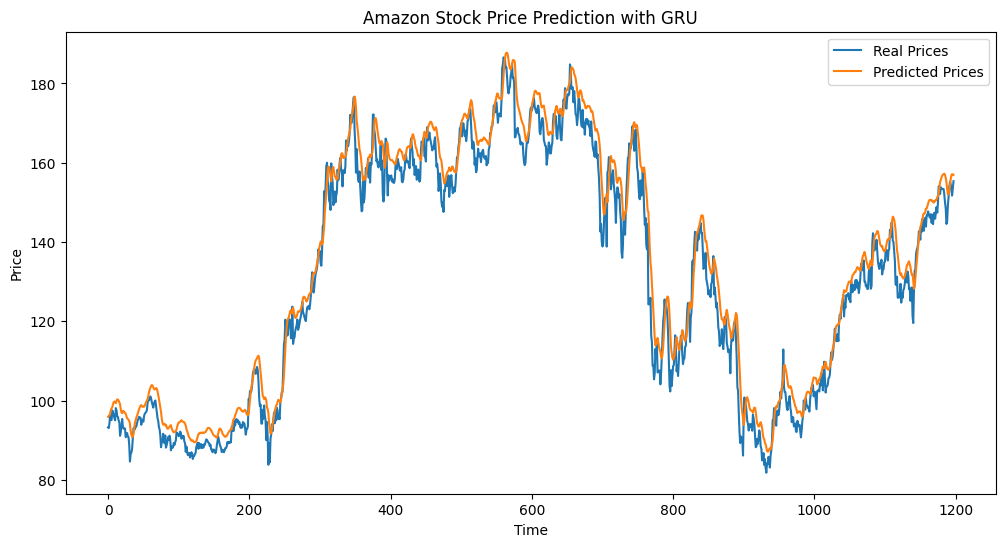

In [20]:
# Plot results
plt.figure(figsize=(12, 6))
plt.plot(real_prices, label='Real Prices')
plt.plot(predicted_prices, label='Predicted Prices')
plt.title('Amazon Stock Price Prediction with GRU')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()
